
# Benchmarking Endo-FM on Kvasir-Capsule (video capsule endoscopy)

This notebook benchmarks the **Endo-FM** video foundation model
([Wang et al., MICCAI 2023](https://arxiv.org/abs/2306.16741),
[med-air/Endo-FM](https://github.com/med-air/Endo-FM)) as a frozen feature
extractor for classifying capsule-endoscopy video frames, using the
**Kvasir-Capsule** dataset ([Smedsrud et al., Scientific Data 2021](https://www.nature.com/articles/s41597-021-00920-z),
[simula/kvasir-capsule](https://github.com/simula/kvasir-capsule)).

Runs locally (dedicated CUDA venv) or on **Google Colab** (auto-detected in
Section 0 -- see README.md for upload/setup steps).

## Why this dataset, and not Endo-FM's own PolypDiag benchmark

Endo-FM's paper reports downstream numbers on **PolypDiag / CVC-12k / KUMC**, but
the preprocessed datasets *and* the fine-tuned checkpoints for all three are
hosted on the authors' personal CUHK SharePoint links, which are **dead**
(`404 FILE NOT FOUND` as of 2026-09-16 — confirmed for all three datasets and
two of the three checkpoint links; a live upstream GitHub issue, #33, has
someone else asking the authors for a fresh copy of the same data). Only the
general **pretrained backbone** (`endo_fm.pth`, Google Drive) is still reachable.
So instead of a paper reproduction, this notebook does an independent linear-probe
benchmark on a dataset that is still live: Kvasir-Capsule.

## What this notebook does

1. Downloads/verifies the Endo-FM ViT-B/16 backbone checkpoint and the
   Kvasir-Capsule **labeled videos** (43 raw procedure videos, ~32GB).
2. Extracts exactly the frames named in Kvasir-Capsule's **official 2-fold
   split** (`official_splits/split_0.csv`, `split_1.csv`) directly from the
   raw video files (matches the community's standard evaluation protocol,
   while still going through real video decoding rather than the
   pre-extracted-images shortcut).
3. Builds a linear probe on top of **frozen** Endo-FM ViT-B/16 CLS-token
   features (each still frame is replicated across the model's 8-frame
   temporal window, since Endo-FM is a video transformer).
4. Runs the official 2-fold protocol (train fold 0 / test fold 1, and vice
   versa) and reports accuracy + macro-F1, per-class breakdown, and a
   confusion matrix.
5. Repeats the same pipeline with a **randomly-initialized** backbone as a
   control, to isolate how much Endo-FM's pretraining is actually buying you
   over the architecture alone.

## What this notebook deliberately does NOT do

The **unlabeled** Kvasir-Capsule videos (74 videos, ~58GB) are downloaded
alongside the labeled set but are **not** used here. They match the "DAPT:
continued self-supervised pretraining on unlabeled video" step described in
this project's `neurosurgery_notegen_architecture.md` (Layer 2) — that's a
much larger, separate undertaking (re-implementing Endo-FM's multi-crop
DINO-style SSL training loop) and is out of scope for a benchmark notebook.
They're staged here so that follow-up work doesn't need to re-download them.


## 0. Setup: paths, device, and package check

On Colab: **Runtime -> Change runtime type -> T4 GPU**, then **Runtime -> Run
all**. This cell auto-detects Colab, mounts Google Drive, points every path at
`/content/drive/MyDrive/endofm-benchmark` (so downloads/extracted frames/results
persist across sessions instead of being redone each time), and installs the
packages Colab doesn't ship by default. Running locally it uses
`E:/endofm-benchmark` and skips both steps -- see README.md for the local venv
setup. See README.md's Colab section for Drive storage requirements.

In [1]:

import os, sys, json, glob, random, subprocess
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/endofm-benchmark")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "einops", "timm", "gdown", "opencv-python-headless"],
        check=True,
    )
else:
    PROJECT_ROOT = Path(r"endofm-benchmark")

ENDOFM_REPO = PROJECT_ROOT / "Endo-FM"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FRAMES_DIR = DATA_DIR / "kvasir-capsule-labeled-videos" / "extracted_frames"
SPLITS_DIR = DATA_DIR / "official_splits"

for d in [CKPT_DIR, DATA_DIR, RESULTS_DIR, FRAMES_DIR, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ENDOFM_REPO))  # so `import models.timesformer` resolves to the cloned repo

import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

random.seed(0)
torch.manual_seed(0)


Mounted at /content/drive
torch: 2.11.0+cu128 | CUDA available: True
Using device: cuda


## 1. Endo-FM repo + pretrained backbone checkpoint

Clones `med-air/Endo-FM` (for the ViT-B/16 TimeSformer model code only —
we don't use its old torch==1.8 / fvcore-based training scripts) and
downloads the pretrained backbone from the authors' Google Drive link.
Both steps are skipped if already present, so re-running this cell is cheap.

In [2]:

if not (ENDOFM_REPO / "models" / "timesformer.py").exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/med-air/Endo-FM.git", str(ENDOFM_REPO)],
        check=True,
    )
else:
    print("Endo-FM repo already present:", ENDOFM_REPO)


Endo-FM repo already present: /content/drive/MyDrive/endofm-benchmark/Endo-FM


In [3]:

CKPT_PATH = CKPT_DIR / "endo_fm.pth"
GDRIVE_ID = "1H7B91Ewm4QkZRsnUk1Bn0IQch5P8C7Xl"  # from Endo-FM README "Pre-trained Weights" link

if not CKPT_PATH.exists():
    import gdown
    gdown.download(id=GDRIVE_ID, output=str(CKPT_PATH), quiet=False)
else:
    print("Checkpoint already present:", CKPT_PATH, f"({CKPT_PATH.stat().st_size / 1e6:.1f} MB)")


Checkpoint already present: /content/drive/MyDrive/endofm-benchmark/checkpoints/endo_fm.pth (2310.4 MB)


## 2. Kvasir-Capsule data

Downloads (if missing) and extracts the **labeled videos** archive from
[datasets.simula.no/kvasir-capsule](https://datasets.simula.no/kvasir-capsule/),
and fetches the official 2-fold split CSVs from
[simula/kvasir-capsule](https://github.com/simula/kvasir-capsule).

> The `datasets.simula.no` TLS certificate doesn't validate on this machine
> (checked directly with curl — an expired/misconfigured cert on their end,
> not a MITM concern for a public, non-interactive dataset download), so the
> download below explicitly disables certificate verification. Don't reuse
> `verify=False` for anything that isn't a known, public, read-only dataset
> mirror like this.

In [4]:

LABELED_VIDEOS_URL = "https://datasets.simula.no/downloads/kvasir-capsule/kvasir-capsule-labeled-videos.zip"
LABELED_VIDEOS_ZIP = DATA_DIR / "kvasir-capsule-labeled-videos.zip"
LABELED_VIDEOS_EXTRACT_DIR = DATA_DIR / "kvasir-capsule-labeled-videos" / "raw"

UNLABELED_VIDEOS_URL = "https://datasets.simula.no/downloads/kvasir-capsule/kvasir-capsule-unlabeled-videos.zip"
UNLABELED_VIDEOS_ZIP = DATA_DIR / "kvasir-capsule-unlabeled-videos.zip"

import requests

def download(url, dest, chunk_mb=8):
    if dest.exists():
        print(f"Already downloaded: {dest} ({dest.stat().st_size / 1e9:.2f} GB)")
        return
    print(f"Downloading {url} -> {dest}")
    with requests.get(url, stream=True, verify=False, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        done = 0
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_mb * 1024 * 1024):
                f.write(chunk)
                done += len(chunk)
                if total:
                    print(f"\r  {done/1e9:.2f} / {total/1e9:.2f} GB", end="")
    print("\nDone.")

download(LABELED_VIDEOS_URL, LABELED_VIDEOS_ZIP)
# download(UNLABELED_VIDEOS_URL, UNLABELED_VIDEOS_ZIP)  # not needed here, see intro


Already downloaded: /content/drive/MyDrive/endofm-benchmark/data/kvasir-capsule-labeled-videos.zip (33.81 GB)


In [5]:
import zipfile

def attempt_extraction(zip_path, extract_dir):
    try:
        print(f"Attempting to extract {zip_path}...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(extract_dir)
        print("Extraction complete.")
        return True
    except zipfile.BadZipFile:
        print(f"Error: {zip_path} is not a valid zip file. It might be corrupted.")
        return False

if not LABELED_VIDEOS_EXTRACT_DIR.exists() or not any(LABELED_VIDEOS_EXTRACT_DIR.rglob("*")):
    LABELED_VIDEOS_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    extracted_successfully = False
    # Try at most twice: once with existing, once after redownload
    for attempt in range(2):
        if attempt > 0: # If this is a retry
            print(f"Deleting corrupted file: {LABELED_VIDEOS_ZIP} and re-downloading...")
            LABELED_VIDEOS_ZIP.unlink(missing_ok=True) # Delete the bad zip file
            # Re-download the file. The download function (from previous cell) will now execute.
            download(LABELED_VIDEOS_URL, LABELED_VIDEOS_ZIP)

        if attempt_extraction(LABELED_VIDEOS_ZIP, LABELED_VIDEOS_EXTRACT_DIR):
            extracted_successfully = True
            break

    if not extracted_successfully:
        raise RuntimeError(f"Failed to extract {LABELED_VIDEOS_ZIP} after {attempt+1} attempts. Please check the URL or your network connection.")

else:
    print("Already extracted:", LABELED_VIDEOS_EXTRACT_DIR)

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")
video_paths = [p for p in LABELED_VIDEOS_EXTRACT_DIR.rglob("*") if p.suffix.lower() in VIDEO_EXTS]
video_id_to_path = {p.stem: p for p in video_paths}
print(f"Found {len(video_id_to_path)} video files.")
print("Example ids:", list(video_id_to_path)[:3])


Already extracted: /content/drive/MyDrive/endofm-benchmark/data/kvasir-capsule-labeled-videos/raw
Found 43 video files.
Example ids: ['dc221ccc65d34010', '48579eec79784294', 'c11b28a8b2344716']


In [6]:

SPLIT_URLS = {
    "split_0": "https://raw.githubusercontent.com/simula/kvasir-capsule/master/official_splits/split_0.csv",
    "split_1": "https://raw.githubusercontent.com/simula/kvasir-capsule/master/official_splits/split_1.csv",
}

for name, url in SPLIT_URLS.items():
    dest = SPLITS_DIR / f"{name}.csv"
    if not dest.exists():
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        dest.write_bytes(r.content)
    print(name, "->", dest)


split_0 -> /content/drive/MyDrive/endofm-benchmark/data/official_splits/split_0.csv
split_1 -> /content/drive/MyDrive/endofm-benchmark/data/official_splits/split_1.csv


## 3. Frame extraction

The official split CSVs reference frames as `<video_id>_<frame_number>.jpg`.
`frame_number` is the raw sequential decode index into that video. We decode
each labeled video once, sequentially, and save out only the frames that
appear in either split (single pass per video — much cheaper than seeking
per-frame in a compressed stream). Results are cached to disk as JPEGs so
this only runs once.

In [7]:

import csv
import cv2
from collections import defaultdict

def load_split(name):
    rows = []
    with open(SPLITS_DIR / f"{name}.csv", newline="") as f:
        for row in csv.DictReader(f):
            video_id, frame_no = row["filename"].rsplit(".", 1)[0].rsplit("_", 1)
            rows.append((video_id, int(frame_no), row["label"]))
    return rows

split0 = load_split("split_0")
split1 = load_split("split_1")
print(f"split_0: {len(split0)} labeled frames | split_1: {len(split1)} labeled frames")

wanted_by_video = defaultdict(set)
for video_id, frame_no, _ in split0 + split1:
    wanted_by_video[video_id].add(frame_no)

missing_videos = [vid for vid in wanted_by_video if vid not in video_id_to_path]
if missing_videos:
    print(f"WARNING: {len(missing_videos)} video ids referenced by the splits were not found "
          f"among the extracted video files, e.g. {missing_videos[:5]}")


split_0: 23061 labeled frames | split_1: 24100 labeled frames


In [8]:

def extract_frames_for_video(video_id, frame_numbers):
    out_dir = FRAMES_DIR / video_id
    remaining = {fn for fn in frame_numbers if not (out_dir / f"{fn}.jpg").exists()}
    if not remaining:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_id_to_path[video_id]))
    idx = 0
    target_max = max(remaining)
    while idx <= target_max:
        ok, frame = cap.read()
        if not ok:
            break
        if idx in remaining:
            cv2.imwrite(str(out_dir / f"{idx}.jpg"), frame)
        idx += 1
    cap.release()

from tqdm import tqdm

for video_id, frame_numbers in tqdm(wanted_by_video.items(), desc="Extracting frames per video"):
    if video_id in video_id_to_path:
        extract_frames_for_video(video_id, frame_numbers)

n_extracted = sum(1 for _ in FRAMES_DIR.rglob("*.jpg"))
print(f"Total extracted frames on disk: {n_extracted}")


Extracting frames per video: 100%|██████████| 43/43 [02:44<00:00,  3.82s/it]


Total extracted frames on disk: 47153


## 4. Endo-FM model

Loads the ViT-B/16 TimeSformer architecture straight from the cloned repo
(`models/timesformer.py`) — this file only depends on `torch` and `einops`,
none of the repo's old fvcore/mmcv/torch==1.8 machinery, since we're not
using its dataset loaders or distributed training scripts.

A single still frame is replicated across `NUM_FRAMES` temporal positions to
form a valid "clip" input, since Endo-FM is a video (not image) transformer.

In [9]:

from models.timesformer import get_vit_base_patch16_224

class SimpleCfg:
    # stand-in for the repo's fvcore CfgNode; only fields get_vit_base_patch16_224 reads
    class DATA:
        TRAIN_CROP_SIZE = 224
        NUM_FRAMES = 8
    class MODEL:
        NUM_CLASSES = 0
    class TIMESFORMER:
        ATTENTION_TYPE = "divided_space_time"
        PRETRAINED_MODEL = ""

def build_backbone(load_checkpoint: bool):
    model = get_vit_base_patch16_224(cfg=SimpleCfg(), no_head=True)
    if load_checkpoint:
        # weights_only=False: older checkpoint format bundling a Namespace + optimizer state;
        # trusted source (Endo-FM authors' own Google Drive release)
        ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
        if "teacher" in ckpt:
            ckpt = ckpt["teacher"]
        state_dict = {k[len("backbone."):]: v for k, v in ckpt.items() if k.startswith("backbone.")}
        msg = model.load_state_dict(state_dict, strict=False)
        print("Loaded Endo-FM weights:", msg)
    model.eval().to(DEVICE)
    return model

NUM_FRAMES = SimpleCfg.DATA.NUM_FRAMES
IMG_SIZE = SimpleCfg.DATA.TRAIN_CROP_SIZE


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 5. Data pipeline: image -> pseudo-clip tensor

In [10]:

import numpy as np
from PIL import Image
import torchvision.transforms as T

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_clip_tensor(frame_path):
    img = Image.open(frame_path).convert("RGB")
    frame = preprocess(img)                      # (C, H, W)
    clip = frame.unsqueeze(1).repeat(1, NUM_FRAMES, 1, 1)  # (C, T, H, W)
    return clip

class KvasirCapsuleFrames(torch.utils.data.Dataset):
    def __init__(self, rows, label_to_idx):
        self.rows = rows
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        video_id, frame_no, label = self.rows[i]
        path = FRAMES_DIR / video_id / f"{frame_no}.jpg"
        return load_clip_tensor(path), self.label_to_idx[label]

all_labels = sorted({label for _, _, label in split0 + split1})
label_to_idx = {label: i for i, label in enumerate(all_labels)}
print(f"{len(all_labels)} classes (Kvasir-Capsule official 2-fold protocol):", all_labels)

def keep_available(rows):
    return [r for r in rows if (FRAMES_DIR / r[0] / f"{r[1]}.jpg").exists()]

split0 = keep_available(split0)
split1 = keep_available(split1)
print(f"Usable frames -- split_0: {len(split0)}, split_1: {len(split1)}")


11 classes (Kvasir-Capsule official 2-fold protocol): ['Angiectasia', 'Blood', 'Erosion', 'Erythematous', 'Foreign Bodies', 'Ileo-cecal valve', 'Lymphangiectasia', 'Normal', 'Pylorus', 'Reduced Mucosal View', 'Ulcer']
Usable frames -- split_0: 23061, split_1: 24100


## 6. Feature extraction

Frozen backbone -> 768-d CLS token per frame. Run once per fold-set, cached
in memory as numpy arrays (14-class / 11-class problem, tens of thousands of
frames of features easily fits in RAM).

In [11]:

MAX_PER_CLASS = None            # None = full official split
CONTROL_MAX_PER_CLASS = 300     # subsampled control, not the headline number
BATCH_SIZE = 8

def maybe_subsample(rows, max_per_class):
    if max_per_class is None:
        return rows
    by_class = defaultdict(list)
    for r in rows:
        by_class[r[2]].append(r)
    out = []
    rng = random.Random(0)
    for label, items in by_class.items():
        rng.shuffle(items)
        out.extend(items[:max_per_class])
    return out

@torch.no_grad()
def extract_features(model, rows, desc, max_per_class):
    rows = maybe_subsample(rows, max_per_class)
    ds = KvasirCapsuleFrames(rows, label_to_idx)
    dl = torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    feats, labels = [], []
    for x, y in tqdm(dl, desc=desc):
        x = x.to(DEVICE)
        f = model(x)  # (B, 768) CLS token, since no_head=True and use_head defaults to False
        feats.append(f.cpu().numpy())
        labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)


## 7. Official 2-fold linear-probe benchmark

Standard Kvasir-Capsule protocol: train on fold 0 / test on fold 1, then
train on fold 1 / test on fold 0, and average. Repeated once with the
pretrained Endo-FM backbone and once with a randomly-initialized backbone of
identical architecture, as a control for how much the pretraining itself is
contributing.

In [12]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def run_2fold(load_checkpoint, tag, max_per_class):
    model = build_backbone(load_checkpoint)
    feats0, labels0 = extract_features(model, split0, f"[{tag}] features fold 0", max_per_class)
    feats1, labels1 = extract_features(model, split1, f"[{tag}] features fold 1", max_per_class)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    fold_results = []
    for (train_f, train_y, test_f, test_y, fold_name) in [
        (feats0, labels0, feats1, labels1, "train=split0,test=split1"),
        (feats1, labels1, feats0, labels0, "train=split1,test=split0"),
    ]:
        clf = LogisticRegression(max_iter=2000, class_weight="balanced")
        clf.fit(train_f, train_y)
        pred = clf.predict(test_f)
        acc = accuracy_score(test_y, pred)
        macro_f1 = f1_score(test_y, pred, average="macro")
        fold_results.append({
            "fold": fold_name, "accuracy": acc, "macro_f1": macro_f1,
            "y_true": test_y, "y_pred": pred,
        })
        print(f"[{tag}] {fold_name}: accuracy={acc:.4f}  macro_f1={macro_f1:.4f}")

    return fold_results





In [13]:
results_endofm = run_2fold(load_checkpoint=True, tag="Endo-FM (pretrained)", max_per_class=MAX_PER_CLASS)

Loaded Endo-FM weights: <All keys matched successfully>


[Endo-FM (pretrained)] features fold 1: 100%|██████████| 3013/3013 [1:32:09<00:00,  1.84s/it]


[Endo-FM (pretrained)] train=split0,test=split1: accuracy=0.6520  macro_f1=0.1593
[Endo-FM (pretrained)] train=split1,test=split0: accuracy=0.6748  macro_f1=0.2197


In [14]:
results_random = run_2fold(load_checkpoint=False, tag="Random init (control)", max_per_class=CONTROL_MAX_PER_CLASS)

[Random init (control)] features fold 1: 100%|██████████| 322/322 [01:21<00:00,  3.95it/s]


[Random init (control)] train=split0,test=split1: accuracy=0.2199  macro_f1=0.1769
[Random init (control)] train=split1,test=split0: accuracy=0.1640  macro_f1=0.1408


## 8. Results summary

In [19]:

import pandas as pd

summary_rows = []
for tag, results in [("Endo-FM (pretrained)", results_endofm), ("Random init (control)", results_random)]:
    accs = [r["accuracy"] for r in results]
    f1s = [r["macro_f1"] for r in results]
    summary_rows.append({
        "model": tag,
        "mean_accuracy": np.mean(accs),
        "mean_macro_f1": np.mean(f1s),
        "fold_accuracies": accs,
        "fold_macro_f1s": f1s,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,model,mean_accuracy,mean_macro_f1,fold_accuracies,fold_macro_f1s
0,Endo-FM (pretrained),0.663384,0.189512,"[0.6519917012448133, 0.6747755951606609]","[0.15934699588540463, 0.2196773968392316]"
1,Random init (control),0.191965,0.158840,"[0.2199299338263916, 0.164]","[0.17688901444117144, 0.1407911477294833]"


In [20]:

print(classification_report(
    np.concatenate([results_endofm[0]["y_true"], results_endofm[1]["y_true"]]),
    np.concatenate([results_endofm[0]["y_pred"], results_endofm[1]["y_pred"]]),
    target_names=all_labels,
    zero_division=0,
))


                      precision    recall  f1-score   support

         Angiectasia       0.07      0.04      0.05       866
               Blood       0.00      0.00      0.00       446
             Erosion       0.01      0.02      0.01       506
        Erythematous       0.01      0.02      0.01       159
      Foreign Bodies       0.10      0.13      0.12       776
    Ileo-cecal valve       0.27      0.30      0.29      4189
    Lymphangiectasia       0.09      0.11      0.10       592
              Normal       0.88      0.83      0.85     34338
             Pylorus       0.28      0.55      0.37      1529
Reduced Mucosal View       0.34      0.18      0.23      2906
               Ulcer       0.12      0.07      0.09       854

            accuracy                           0.66     47161
           macro avg       0.20      0.20      0.19     47161
        weighted avg       0.70      0.66      0.68     47161



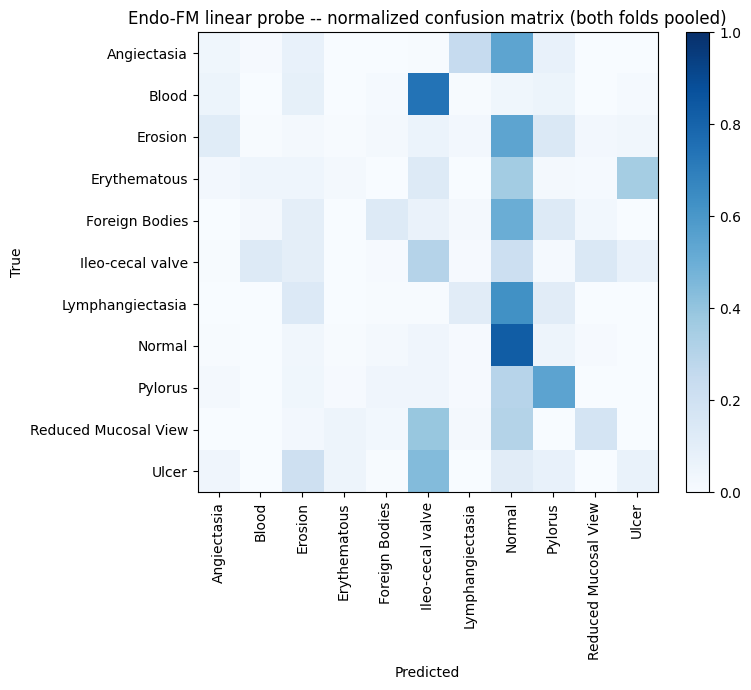

In [21]:

import matplotlib.pyplot as plt

y_true_all = np.concatenate([results_endofm[0]["y_true"], results_endofm[1]["y_true"]])
y_pred_all = np.concatenate([results_endofm[0]["y_pred"], results_endofm[1]["y_pred"]])
cm = confusion_matrix(y_true_all, y_pred_all, normalize="true")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(all_labels))); ax.set_xticklabels(all_labels, rotation=90)
ax.set_yticks(range(len(all_labels))); ax.set_yticklabels(all_labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Endo-FM linear probe -- normalized confusion matrix (both folds pooled)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()


In [22]:

out = {
    "endofm": {
        "mean_accuracy": float(np.mean([r["accuracy"] for r in results_endofm])),
        "mean_macro_f1": float(np.mean([r["macro_f1"] for r in results_endofm])),
        "folds": [{"fold": r["fold"], "accuracy": r["accuracy"], "macro_f1": r["macro_f1"]} for r in results_endofm],
    },
    "random_init_control": {
        "mean_accuracy": float(np.mean([r["accuracy"] for r in results_random])),
        "mean_macro_f1": float(np.mean([r["macro_f1"] for r in results_random])),
        "folds": [{"fold": r["fold"], "accuracy": r["accuracy"], "macro_f1": r["macro_f1"]} for r in results_random],
    },
    "classes": all_labels,
    "n_train_test_frames": {"split_0": len(split0), "split_1": len(split1)},
}
with open(RESULTS_DIR / "benchmark_results.json", "w") as f:
    json.dump(out, f, indent=2)
print(json.dumps(out, indent=2))


{
  "endofm": {
    "mean_accuracy": 0.6633836482027371,
    "mean_macro_f1": 0.1895121963623181,
    "folds": [
      {
        "fold": "train=split0,test=split1",
        "accuracy": 0.6519917012448133,
        "macro_f1": 0.15934699588540463
      },
      {
        "fold": "train=split1,test=split0",
        "accuracy": 0.6747755951606609,
        "macro_f1": 0.2196773968392316
      }
    ]
  },
  "random_init_control": {
    "mean_accuracy": 0.1919649669131958,
    "mean_macro_f1": 0.15884008108532738,
    "folds": [
      {
        "fold": "train=split0,test=split1",
        "accuracy": 0.2199299338263916,
        "macro_f1": 0.17688901444117144
      },
      {
        "fold": "train=split1,test=split0",
        "accuracy": 0.164,
        "macro_f1": 0.1407911477294833
      }
    ]
  },
  "classes": [
    "Angiectasia",
    "Blood",
    "Erosion",
    "Erythematous",
    "Foreign Bodies",
    "Ileo-cecal valve",
    "Lymphangiectasia",
    "Normal",
    "Pylorus",
    "Reduced

In [24]:
import joblib
from datetime import datetime, timezone

# Train on BOTH folds combined -- everything the 2-fold CV above already used.
# This is the deployable artifact, not a new accuracy estimate (its own
# training accuracy is meaningless since it includes its own test data;
# the 2-fold numbers above remain the accuracy figure to cite).
full_feats = np.concatenate([endofm_features["feats0"], endofm_features["feats1"]])
full_labels = np.concatenate([endofm_features["labels0"], endofm_features["labels1"]])

final_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
final_clf.fit(full_feats, full_labels)

ARTIFACT_DIR = RESULTS_DIR / "final_model"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(final_clf, ARTIFACT_DIR / "linear_probe.joblib")

with open(ARTIFACT_DIR / "label_mapping.json", "w") as f:
    json.dump({"all_labels": all_labels, "label_to_idx": label_to_idx}, f, indent=2)

metadata = {
    "backbone_checkpoint": str(CKPT_PATH),
    "feature_dim": int(full_feats.shape[1]),
    "n_training_frames": int(full_feats.shape[0]),
    "classes": all_labels,
    "sklearn_logistic_regression_params": final_clf.get_params(),
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
}
with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved final linear probe to:", ARTIFACT_DIR)
print("  linear_probe.joblib  -- trained sklearn LogisticRegression")
print("  label_mapping.json   -- class index <-> class name")
print("  metadata.json        -- backbone/checkpoint provenance + training config")

# To reload and use later:
#   clf = joblib.load(ARTIFACT_DIR / "linear_probe.joblib")
#   with open(ARTIFACT_DIR / "label_mapping.json") as f:
#       mapping = json.load(f)
#   idx_to_label = {v: k for k, v in mapping["label_to_idx"].items()}
#   pred_idx = clf.predict(new_feats)          # new_feats: (N, 768) CLS-token features
#   pred_label = [idx_to_label[i] for i in pred_idx]

NameError: name 'endofm_features' is not defined